# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.

**This file is the completed solutions notebook for submission.** Assignment text is unchanged; every `YOUR ANSWER` cell is filled and followed by the requested explanation.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [2]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [3]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer
import imageio

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")


Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [4]:
# Q1. Current UTC and IIT Kanpur time
now = Time.now()

print("ISO UTC:", now.utc.isot)
print("IIT Kanpur civil clock:", format_iitk(now))
print("Same instant labelled UTC:", format_utc(now))


ISO UTC: 2026-09-06T04:34:13.242
IIT Kanpur civil clock: 2026-09-06 10:04:13 IST
Same instant labelled UTC: 2026-09-06 04:34:13 UTC


**Explanation.** `Time.now()` is called once and that single instant is formatted two ways. Two separate calls need not describe the same instant because each call reads the system clock independently; any elapsed processing time makes the second reading later.




## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [5]:
# Q2. Physical quantities and unit conversions
gtc_height = 2396 * u.m
wavelength_opt = 600 * u.nm
coord_uncertainty = 5 * u.mas
cadence = 10 * u.min
radio_freq = 1.4 * u.GHz

height_km = gtc_height.to(u.km)
wavelength_thz = wavelength_opt.to(u.THz, equivalencies=u.spectral())
uncertainty_arcsec = coord_uncertainty.to(u.arcsec)
cadence_hour = cadence.to(u.hour)
radio_wavelength_cm = radio_freq.to(u.cm, equivalencies=u.spectral())

print(f"GTC height:              {gtc_height}  ->  {height_km}")
print(f"Optical wavelength:      {wavelength_opt}  ->  {wavelength_thz}")
print(f"Coordinate uncertainty:  {coord_uncertainty}  ->  {uncertainty_arcsec}")
print(f"Cadence:                 {cadence}  ->  {cadence_hour}")
print(f"Radio frequency:         {radio_freq}  ->  {radio_wavelength_cm}")


GTC height:              2396.0 m  ->  2.396 km
Optical wavelength:      600.0 nm  ->  499.6540966666666 THz
Coordinate uncertainty:  5.0 mas  ->  0.005 arcsec
Cadence:                 10.0 min  ->  0.16666666666666666 h
Radio frequency:         1.4 GHz  ->  21.413747 cm


**Explanation.** Each value is stored as an Astropy `Quantity` so the unit travels with the number. `u.spectral()` supplies the equivalency that converts wavelength $\leftrightarrow$ frequency through $c=\lambda\nu$.


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [6]:
# Q3. UTC, JD, MJD, IST, and time arithmetic
planning_start = Time(START_UTC, scale="utc")

print("Planning start UTC:", format_utc(planning_start))
print("Julian Date JD:", planning_start.jd)
print("Modified Julian Date MJD:", planning_start.mjd)
print("IIT Kanpur time:", format_iitk(planning_start))

planning_later = planning_start + 2.25 * u.hour
print("2.25 h later UTC:", format_utc(planning_later))
print("2.25 h later IST:", format_iitk(planning_later))

ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
planning_roundtrip = Time(ist_datetime)
roundtrip_offset = np.abs((planning_roundtrip - planning_start).to_value(u.us))
print(f"IST datetime -> Time offset: {roundtrip_offset:.6f} us")
print("Round-trip change is < 1 us:", roundtrip_offset < 1.0)


Planning start UTC: 2026-08-30 12:00:00 UTC
Julian Date JD: 2461283.0
Modified Julian Date MJD: 61282.5
IIT Kanpur time: 2026-08-30 17:30:00 IST
2.25 h later UTC: 2026-08-30 14:15:00 UTC
2.25 h later IST: 2026-08-30 19:45:00 IST
IST datetime -> Time offset: 0.000000 us
Round-trip change is < 1 us: True


**Explanation.** JD and MJD are continuous day counts for the same UTC instant (MJD = JD − 2,400,000.5). Adding `2.25 * u.hour` keeps the time scale consistent. Converting that instant to an IST-aware Python datetime and back recovers the same moment to much better than one microsecond, so the timezone conversion is only a civil-clock label.


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [7]:
# Q4. Parse angles and construct an ICRS coordinate
ra_angle = Angle(FRB_RA_J2000)
dec_angle = Angle(FRB_DEC_J2000)
frb_icrs = SkyCoord(ra=ra_angle, dec=dec_angle, frame="icrs")

print("RA (deg):", frb_icrs.ra.to_value(u.deg))
print("Dec (deg):", frb_icrs.dec.to_value(u.deg))
print(
    "RA (sexagesimal):",
    frb_icrs.ra.to_string(unit=u.hourangle, sep="hms", pad=True, precision=4),
)
print(
    "Dec (sexagesimal):",
    frb_icrs.dec.to_string(unit=u.deg, sep="dms", pad=True, precision=4, alwayssign=True),
)

ra_check = np.abs(frb_icrs.ra.to_value(u.deg) - 347.2704120833) < 1e-8
dec_check = np.abs(frb_icrs.dec.to_value(u.deg) - 48.7066410556) < 1e-8
print("RA matches 347.2704120833 deg within 1e-8 deg:", ra_check)
print("Dec matches +48.7066410556 deg within 1e-8 deg:", dec_check)


RA (deg): 347.27041208333327
Dec (deg): 48.70664105555556
RA (sexagesimal): 23h09m04.8989s
Dec (sexagesimal): +48d42m23.9078s
RA matches 347.2704120833 deg within 1e-8 deg: True
Dec matches +48.7066410556 deg within 1e-8 deg: True


**Explanation.** Right ascension is an equatorial longitude locked to Earth's rotation: $24^{\mathrm{h}}=360^\circ$, so hours are the natural unit and match Local Sidereal Time. Declination is a latitude-like angle from the celestial equator, so degrees are the natural unit.


## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [8]:
# Q5. ICRS to Galactic and back
frb_galactic = frb_icrs.galactic
print("Galactic longitude l (deg):", frb_galactic.l.to_value(u.deg))
print("Galactic latitude  b (deg):", frb_galactic.b.to_value(u.deg))

frb_icrs_roundtrip = frb_galactic.transform_to("icrs")
galactic_residual_uas = frb_icrs.separation(frb_icrs_roundtrip).to(u.uas)
print("Round-trip ICRS separation:", galactic_residual_uas)


Galactic longitude l (deg): 106.06496077332801
Galactic latitude  b (deg): -10.784176285402491
Round-trip ICRS separation: 0.000289774 uas


**Explanation.** A tiny non-zero residual is numerical rounding in the rotation matrices, not a physical shift of the source. The published ICRS position is unchanged.


## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [9]:
# Q6. ICRS to Ecliptic and back
frb_ecliptic = frb_icrs.transform_to(BarycentricTrueEcliptic(equinox="J2000"))
ecliptic_lon = frb_ecliptic.lon
ecliptic_lat = frb_ecliptic.lat

print("Ecliptic longitude lambda (deg):", ecliptic_lon.to_value(u.deg))
print("Ecliptic latitude  beta   (deg):", ecliptic_lat.to_value(u.deg))
print(
    "Longitude in [0, 360):",
    (ecliptic_lon.wrap_at(360 * u.deg).degree >= 0)
    and (ecliptic_lon.wrap_at(360 * u.deg).degree < 360),
)
print(
    "Latitude in [-90, 90]:",
    (ecliptic_lat.degree >= -90) and (ecliptic_lat.degree <= 90),
)

frb_from_ecliptic = frb_ecliptic.transform_to("icrs")
ecliptic_residual_uas = frb_icrs.separation(frb_from_ecliptic).to(u.uas)
print("Round-trip ICRS separation:", ecliptic_residual_uas)


Ecliptic longitude lambda (deg): 14.411187650340105
Ecliptic latitude  beta   (deg): 48.34695843744783
Longitude in [0, 360): True
Latitude in [-90, 90]: True
Round-trip ICRS separation: 0 uas


**Explanation.** The ecliptic is Earth's orbital plane around the Sun. Ecliptic latitude $\beta$ is the angular height of the source above that plane; $\beta=0$ would place the FRB on the ecliptic.


## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [10]:
# Q7. Angular separation
earlier_position = SkyCoord(
    ra=EARLIER_POSITION_RA,
    dec=EARLIER_POSITION_DEC,
    frame="icrs",
)

alpha_1 = frb_icrs.ra.radian
delta_1 = frb_icrs.dec.radian
alpha_2 = earlier_position.ra.radian
delta_2 = earlier_position.dec.radian

cos_delta_theta = (
    np.sin(delta_1) * np.sin(delta_2)
    + np.cos(delta_1) * np.cos(delta_2) * np.cos(alpha_2 - alpha_1)
)
cos_delta_theta = np.clip(cos_delta_theta, -1.0, 1.0)
delta_theta = np.arccos(cos_delta_theta) * u.rad

print("Manual separation:", delta_theta.to(u.arcsec), "=", delta_theta.to(u.mas))

astropy_separation = frb_icrs.separation(earlier_position)
print("Astropy separation:", astropy_separation.to(u.arcsec), "=", astropy_separation.to(u.mas))

agreement = np.abs((delta_theta - astropy_separation).to_value(u.arcsec)) < 1e-6
print("Agreement within 1e-6 arcsec:", agreement)


Manual separation: 1.4922406144066507 arcsec = 1492.2406144066504 mas
Astropy separation: 1.49224 arcsec = 1492.24 mas
Agreement within 1e-6 arcsec: True


**Explanation.** The cosine formula is the spherical law of cosines on the celestial sphere. Clipping the cosine to $[-1,1]$ protects `arccos` from tiny floating-point overshoots. The VLBI position and the earlier sexagesimal rounding differ by only a few milliarcseconds.


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [11]:
# Q8. Define the GTC observing site
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m,
)

print("Recovered longitude:", gtc_location.lon)
print("Recovered latitude:", gtc_location.lat)
print("Recovered height:", gtc_location.height)
print("Geocentric representation:", gtc_location)


Recovered longitude: -17d53m20.4s
Recovered latitude: 28d45m28.8s
Recovered height: 2395.9999999998504 m
Geocentric representation: (5327253.44883116, -1719526.5938017343, 3051567.70055982) m


**Explanation.** A negative geodetic longitude means the site lies west of the Greenwich meridian. GTC is in the Canary Islands, so $\lambda=-17.889^\circ$ is $17.889^\circ$ west.


## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [12]:
# Q9. GTC LST and hour angle at one instant
instant_q9 = Time("2026-08-31T00:00:00", scale="utc")
lst_q9 = instant_q9.sidereal_time("apparent", longitude=gtc_location.lon)
hour_angle_q9 = (lst_q9 - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC:", format_utc(instant_q9))
print("IIT Kanpur time:", format_iitk(instant_q9))
print("Apparent GTC LST:", lst_q9)
print("Hour angle H = LST - RA (wrapped to +/-12 h):", hour_angle_q9)

if np.isclose(hour_angle_q9.hour, 0.0, atol=1e-6):
    meridian_state = "transiting"
elif hour_angle_q9.hour < 0:
    meridian_state = "east of the meridian (still rising toward transit)"
else:
    meridian_state = "west of the meridian (already past transit)"
print("Meridian state from sign of H:", meridian_state)


UTC: 2026-08-31 00:00:00 UTC
IIT Kanpur time: 2026-08-31 05:30:00 IST
Apparent GTC LST: 21h25m12.23600049s
Hour angle H = LST - RA (wrapped to +/-12 h): -1h43m52.66289951s
Meridian state from sign of H: east of the meridian (still rising toward transit)


**Explanation.** Hour angle is $H=\mathrm{LST}-\alpha$, wrapped to $\pm12^{\mathrm{h}}$. $H<0$ means the source is still east of the meridian, $H=0$ is transit, and $H>0$ means it is west of the meridian.


## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [13]:
# Q10. Nearest sampled meridian transit
gtc_lst = times.sidereal_time("apparent", longitude=gtc_location.lon)
hour_angle = (gtc_lst - frb_icrs.ra).wrap_at(12 * u.hourangle)
transit_index = int(np.argmin(np.abs(hour_angle.hour)))

print("Nearest sampled transit index:", transit_index)
print("UTC:", format_utc(times[transit_index]))
print("IIT Kanpur time:", format_iitk(times[transit_index]))
print("Apparent GTC LST:", gtc_lst[transit_index])
print("Hour angle:", hour_angle[transit_index])
print("|H| at this sample (sidereal minutes):", np.abs(hour_angle[transit_index].hour) * 60.0)


Nearest sampled transit index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur time: 2026-08-31 07:10:00 IST
Apparent GTC LST: 23h05m28.66291538s
Hour angle: -0h03m36.23598462s
|H| at this sample (sidereal minutes): 3.6039330770191924


**Explanation.** This is only the nearest point on the 10-minute course grid. The true $H=0$ instant generally falls between two samples, so the printed time is a sampled approximation rather than the exact geometric transit.


## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [14]:
# Q11. Transit altitude and zenith distance
phi = gtc_location.lat
delta = frb_icrs.dec
h_transit_analytic = (90 * u.deg) - np.abs(phi - delta)
z_transit_analytic = (90 * u.deg) - h_transit_analytic

print("Analytic transit altitude h:", h_transit_analytic.to(u.deg))
print("Analytic zenith distance z = 90 deg - h:", z_transit_analytic.to(u.deg))

altaz_frame = AltAz(obstime=times, location=gtc_location)
frb_gtc_altaz = frb_icrs.transform_to(altaz_frame)

max_alt_index = int(np.argmax(frb_gtc_altaz.alt.degree))
h_sampled_max = frb_gtc_altaz.alt[max_alt_index]
z_sampled_max = (90 * u.deg) - h_sampled_max

print("Largest sampled altitude index:", max_alt_index)
print("Largest sampled altitude UTC:", format_utc(times[max_alt_index]))
print("Largest sampled altitude IST:", format_iitk(times[max_alt_index]))
print("Largest sampled altitude:", h_sampled_max.to(u.deg))
print("Corresponding zenith distance:", z_sampled_max.to(u.deg))
print(
    "Analytic minus sampled altitude (deg):",
    (h_transit_analytic - h_sampled_max).to_value(u.deg),
)


Analytic transit altitude h: 70d03m04.8922s
Analytic zenith distance z = 90 deg - h: 19d56m55.1078s
Largest sampled altitude index: 82
Largest sampled altitude UTC: 2026-08-31 01:40:00 UTC
Largest sampled altitude IST: 2026-08-31 07:10:00 IST
Largest sampled altitude: 69d53m02.08223311s
Corresponding zenith distance: 20d06m57.91776689s
Analytic minus sampled altitude (deg): 0.16744721302501375


**Explanation.** At upper culmination the source's zenith distance equals the absolute difference between site latitude and declination, so $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$. The sampled maximum is slightly lower if the exact transit falls between 10-minute ticks.


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [16]:
# Q12. Altitude before, at, and after transit
samples_two_hours = int((2 * u.hour / step).to_value(u.dimensionless_unscaled))
q12_indices = {
    "two hours before transit": transit_index - samples_two_hours,
    "nearest transit": transit_index,
    "two hours after transit": transit_index + samples_two_hours,
}

print(f"{'epoch':>28s}  {'UTC':>23s}  {'IST':>23s}  {'H (h)':>8s}  "
      f"{'h_calc':>8s}  {'h_apr':>8s}  {'dh deg':>10s}")

for label, idx in q12_indices.items():
    if idx < 0 or idx >= len(times):
        raise IndexError(f"{label} sample {idx} is outside the course grid")
    H = hour_angle[idx]
    sin_h = (
        np.sin(phi.radian) * np.sin(delta.radian)
        + np.cos(phi.radian) * np.cos(delta.radian) * np.cos(H.radian)
    )
    h_calc = np.arcsin(np.clip(sin_h, -1.0, 1.0)) * u.rad
    h_astropy = frb_gtc_altaz.alt[idx]
    dh = (h_calc - h_astropy).to(u.deg)
    print(
        f"{label:>28s}  {format_utc(times[idx]):>23s}  {format_iitk(times[idx]):>23s}  "
        f"{H.hour:8.4f}  {h_calc.to_value(u.deg):8.4f}  {h_astropy.to_value(u.deg):8.4f}  "
        f"{dh.to_value(u.deg):10.4e}"
    )


                       epoch                      UTC                      IST     H (h)    h_calc     h_apr      dh deg
    two hours before transit  2026-08-30 23:40:00 UTC  2026-08-31 05:10:00 IST   -2.0655   59.0320   58.7816  2.5038e-01
             nearest transit  2026-08-31 01:40:00 UTC  2026-08-31 07:10:00 IST   -0.0601   70.0394   69.8839  1.5544e-01
     two hours after transit  2026-08-31 03:40:00 UTC  2026-08-31 09:10:00 IST    1.9454   60.0630   60.1625  -9.9563e-02


**Explanation.** Altitude is highest at meridian transit and is nearly symmetric two hours before and after. That is the geometric signature of a source crossing the meridian: it rises toward the north–south line and then descends on the western side.


## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [18]:
# Q13. How long the source stays above 20 degrees

h_min = MIN_TARGET_ALTITUDE_DEG * u.deg

# Convert all angles to radians for NumPy
h_rad = h_min.to_value(u.rad)
phi_rad = phi.to_value(u.rad)
delta_rad = delta.to_value(u.rad)

cos_H0 = (
    (np.sin(h_rad) - np.sin(phi_rad) * np.sin(delta_rad))
    / (np.cos(phi_rad) * np.cos(delta_rad))
)

print("cos H0:", cos_H0)

if np.abs(cos_H0) > 1:
    if cos_H0 < -1:
        print("Source never drops to 20 deg; it stays above the limit all day.")
    else:
        print("Source never reaches 20 deg from GTC.")
else:
    H0 = np.arccos(np.clip(cos_H0, -1.0, 1.0)) * u.rad

    H0_deg = H0.to(u.deg)
    H0_sidereal_hour = H0.to(u.hourangle)

    total_above_20 = 2 * H0_sidereal_hour

    n_above_20 = int(
        np.count_nonzero(
            frb_gtc_altaz.alt.degree >= MIN_TARGET_ALTITUDE_DEG
        )
    )

    grid_duration = n_above_20 * STEP_MINUTES * u.min

    print("H0 (deg):", H0_deg)
    print("H0 (sidereal hours):", H0_sidereal_hour)
    print("Estimated interval 2 H0 (sidereal hours):", total_above_20)
    print("Grid samples with h >= 20 deg:", n_above_20)
    print("Grid duration at 10 min/sample:", grid_duration.to(u.hour))


cos H0: -0.03363447508056853
H0 (deg): 91.92747700350237 deg
H0 (sidereal hours): 6.128498466900159 hourangle
Estimated interval 2 H0 (sidereal hours): 12.256996933800318 hourangle
Grid samples with h >= 20 deg: 74
Grid duration at 10 min/sample: 12.333333333333334 h


**Explanation.** $H_0$ is the hour angle at which the altitude equals $20^\circ$. The source is above that limit between $-H_0$ and $+H_0$, so the geometric window is $2H_0$ sidereal hours. The 10-minute solar-time grid is a discrete sample of the same window and therefore differs by a fraction of a cadence step (and by the small sidereal-versus-solar offset).


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [19]:
# Q14. Physically safe target airmass
target_airmass = np.asarray(frb_gtc_altaz.secz, dtype=float)
unsafe = (
    (frb_gtc_altaz.alt.degree <= 0.0)
    | ~np.isfinite(target_airmass)
    | (target_airmass < 1.0)
)
target_airmass = target_airmass.copy()
target_airmass[unsafe] = np.nan

finite_airmass = target_airmass[np.isfinite(target_airmass)]
print("Finite airmass range: "
      f"{np.min(finite_airmass):.6f} to {np.max(finite_airmass):.6f}")

best_airmass_index = int(np.nanargmin(target_airmass))
print("Best airmass X:", target_airmass[best_airmass_index])
print("Best airmass UTC:", format_utc(times[best_airmass_index]))
print("Best airmass IST:", format_iitk(times[best_airmass_index]))

n_permitted_airmass = int(
    np.count_nonzero(
        np.isfinite(target_airmass)
        & (target_airmass >= 1.0)
        & (target_airmass <= MAX_AIRMASS)
    )
)
print("Samples with 1 <= X <= 2.5:", n_permitted_airmass)


Finite airmass range: 1.064965 to 55.341587
Best airmass X: 1.0649653147153335
Best airmass UTC: 2026-08-31 01:40:00 UTC
Best airmass IST: 2026-08-31 07:10:00 IST
Samples with 1 <= X <= 2.5: 68


**Explanation.** `secz` is $\sec z$ and is only a meaningful airmass above the horizon, where $X\ge 1$. Below the horizon the path does not go through the local atmosphere, and `secz` becomes negative, infinite, or otherwise non-physical, so those entries must be replaced by `NaN`.


### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [20]:
# Q15. Sun and Moon observing conditions
with solar_system_ephemeris.set("builtin"):
    sun_icrs = get_sun(times)
    moon_topo = get_body("moon", times, location=gtc_location)
    moon_geo = get_body("moon", times)

sun_altaz = sun_icrs.transform_to(altaz_frame)
moon_altaz = moon_topo.transform_to(altaz_frame)

sun_altitude = sun_altaz.alt
moon_altitude = moon_altaz.alt
moon_separation = moon_topo.separation(frb_icrs)

elongation = sun_icrs.separation(moon_geo)
illuminated_fraction = (1.0 - np.cos(elongation.radian)) / 2.0

moon_airmass = np.asarray(moon_altaz.secz, dtype=float)
moon_unsafe = (
    (moon_altitude.degree <= 0.0)
    | ~np.isfinite(moon_airmass)
    | (moon_airmass < 1.0)
    | (moon_airmass > 3.0)
)
moon_airmass[moon_unsafe] = np.nan


def classify_moon(moon_alt_deg, moon_sep_deg, fraction):
    labels = np.empty(len(moon_alt_deg), dtype=object)
    for i in range(len(moon_alt_deg)):
        alt_i = moon_alt_deg[i]
        sep_i = moon_sep_deg[i]
        frac_i = fraction[i]
        if not (np.isfinite(alt_i) and np.isfinite(sep_i) and np.isfinite(frac_i)):
            labels[i] = "Unknown"
            continue
        bright = ((frac_i >= 0.70) and (alt_i > 10.0)) or (sep_i <= 45.0)
        dark = (alt_i < 0.0) or ((sep_i >= 90.0) and (frac_i <= 0.25))
        label = "Gray"
        if bright:
            label = "Bright"
        if dark:
            label = "Dark"
        labels[i] = label
    return labels


moon_label = classify_moon(
    moon_altitude.to_value(u.deg),
    moon_separation.to_value(u.deg),
    np.asarray(illuminated_fraction, dtype=float),
)

print("At nearest sampled transit:")
print("  UTC:", format_utc(times[transit_index]))
print("  IST:", format_iitk(times[transit_index]))
print("  Sun altitude (deg):", sun_altitude[transit_index].to_value(u.deg))
print("  Moon altitude (deg):", moon_altitude[transit_index].to_value(u.deg))
print("  Moon airmass:", moon_airmass[transit_index])
print("  Moon-target separation (deg):", moon_separation[transit_index].to_value(u.deg))
print("  Illuminated fraction:", float(np.asarray(illuminated_fraction)[transit_index]))
print("  Moon label:", moon_label[transit_index])
print("Moon-label counts:", {name: int(np.sum(moon_label == name))
                             for name in ("Dark", "Bright", "Gray", "Unknown")})


At nearest sampled transit:
  UTC: 2026-08-31 01:40:00 UTC
  IST: 2026-08-31 07:10:00 IST
  Sun altitude (deg): -51.95590712438015
  Moon altitude (deg): 59.09598911676852
  Moon airmass: 1.1654618357388418
  Moon-target separation (deg): 45.2267528334598
  Illuminated fraction: 0.9081719061722797
  Moon label: Bright
Moon-label counts: {'Dark': 67, 'Bright': 73, 'Gray': 5, 'Unknown': 0}


 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

**Explanation.** Sun and Moon altitudes come from the built-in ephemeris transformed into the GTC `AltAz` frame. The illuminated fraction $f=(1-\cos\epsilon)/2$ uses the geocentric Sun–Moon elongation $\epsilon$. Course labels apply `Bright` first and `Dark` second, so a sample that matches both rules is `Dark`.


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [21]:
# Q16. Visibility function
def visibility(altitude, airmass, sun_altitude, moon_separation):
    """Return True only where all four GTC observing conditions pass."""

    def as_1d(name, values):
        if hasattr(values, "to_value"):
            values = values.value
        array = np.asarray(values)
        if array.ndim != 1:
            raise ValueError(f"{name} must be a one-dimensional array")
        return array

    altitude = as_1d("altitude", altitude)
    airmass = as_1d("airmass", airmass)
    sun_altitude = as_1d("sun_altitude", sun_altitude)
    moon_separation = as_1d("moon_separation", moon_separation)

    lengths = {altitude.size, airmass.size, sun_altitude.size, moon_separation.size}
    if len(lengths) != 1:
        raise ValueError("altitude, airmass, sun_altitude, and moon_separation must have equal length")

    return (
        (altitude >= MIN_TARGET_ALTITUDE_DEG)
        & (np.isfinite(airmass) & (airmass >= 1.0) & (airmass <= MAX_AIRMASS))
        & (sun_altitude <= MAX_SUN_ALTITUDE_DEG)
        & (moon_separation >= MIN_MOON_SEPARATION_DEG)
    )


preferred_visibility = visibility(
    frb_gtc_altaz.alt.degree,
    target_airmass,
    sun_altitude.degree,
    moon_separation.degree,
)

n_alt = int(np.count_nonzero(frb_gtc_altaz.alt.degree >= MIN_TARGET_ALTITUDE_DEG))
n_x = int(
    np.count_nonzero(
        np.isfinite(target_airmass)
        & (target_airmass >= 1.0)
        & (target_airmass <= MAX_AIRMASS)
    )
)
n_sun = int(np.count_nonzero(sun_altitude.degree <= MAX_SUN_ALTITUDE_DEG))
n_moon = int(np.count_nonzero(moon_separation.degree >= MIN_MOON_SEPARATION_DEG))
n_all = int(np.count_nonzero(preferred_visibility))

print("Samples with altitude >= 20 deg:", n_alt)
print("Samples with 1 <= X <= 2.5:", n_x)
print("Samples with Sun altitude <= -18 deg:", n_sun)
print("Samples with Moon separation >= 30 deg:", n_moon)
print("Samples passing all four conditions:", n_all)
print("Overall observable in this 24 h case?:", "yes" if n_all > 0 else "no")


Samples with altitude >= 20 deg: 74
Samples with 1 <= X <= 2.5: 68
Samples with Sun altitude <= -18 deg: 51
Samples with Moon separation >= 30 deg: 145
Samples passing all four conditions: 51
Overall observable in this 24 h case?: yes


**Explanation.** Each comparison is wrapped in parentheses and combined with `&` so NumPy evaluates the test element-wise. Python `and` cannot combine arrays. A sample is observable only when altitude, airmass, astronomical darkness, and Moon separation all pass together.


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [22]:
# Q17. Does transit automatically mean visible?
instant_west = Time("2026-08-31T06:00:00", scale="utc")
west_index = int(np.argmin(np.abs((times - instant_west).to_value(u.min))))
if not np.isclose((times[west_index] - instant_west).to_value(u.s), 0.0, atol=1.0):
    raise RuntimeError("2026-08-31T06:00:00Z is not on the course grid")


def report_visibility_instant(label, index):
    alt = frb_gtc_altaz.alt[index].to_value(u.deg)
    x = target_airmass[index]
    sun_h = sun_altitude[index].to_value(u.deg)
    moon_sep = moon_separation[index].to_value(u.deg)
    cond_alt = alt >= MIN_TARGET_ALTITUDE_DEG
    cond_x = bool(np.isfinite(x) and (1.0 <= x <= MAX_AIRMASS))
    cond_sun = sun_h <= MAX_SUN_ALTITUDE_DEG
    cond_moon = moon_sep >= MIN_MOON_SEPARATION_DEG
    final = bool(preferred_visibility[index])

    print(f"--- {label} ---")
    print("UTC:", format_utc(times[index]))
    print("IST:", format_iitk(times[index]))
    print(f"Altitude (deg): {alt:.4f}   pass={cond_alt}")
    print(f"Airmass X: {x}   pass={cond_x}")
    print(f"Sun altitude (deg): {sun_h:.4f}   pass={cond_sun}")
    print(f"Moon separation (deg): {moon_sep:.4f}   pass={cond_moon}")
    print("preferred_visibility:", final)
    print()


report_visibility_instant("nearest sampled transit (Q10)", transit_index)
report_visibility_instant("western-sky sample 2026-08-31T06:00:00Z", west_index)


--- nearest sampled transit (Q10) ---
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Altitude (deg): 69.8839   pass=True
Airmass X: 1.0649653147153335   pass=True
Sun altitude (deg): -51.9559   pass=True
Moon separation (deg): 45.2268   pass=True
preferred_visibility: True

--- western-sky sample 2026-08-31T06:00:00Z ---
UTC: 2026-08-31 06:00:00 UTC
IST: 2026-08-31 11:30:00 IST
Altitude (deg): 37.9864   pass=True
Airmass X: 1.6247626802375212   pass=True
Sun altitude (deg): -11.2819   pass=False
Moon separation (deg): 44.6981   pass=True
preferred_visibility: False



**Explanation.** Meridian transit maximises geometric altitude, but observability also requires a permitted airmass, astronomical darkness, and enough Moon–target separation. High altitude or $H\approx 0$ alone cannot guarantee that the Sun is down or that the Moon is far enough away, so transit is necessary geometry, not a complete observing decision.


# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Number of observable windows: 1
Window 1:
  IST: 2026-08-31 02:30:00 IST -> 2026-08-31 10:50:00 IST
  UTC: 2026-08-30 21:00:00 UTC -> 2026-08-31 05:20:00 UTC
  Sample-centre duration: 8.333333333333332 h
  Samples in window: 51
  Best target airmass: 1.0649653147153335
  Midpoint Moon label: Bright


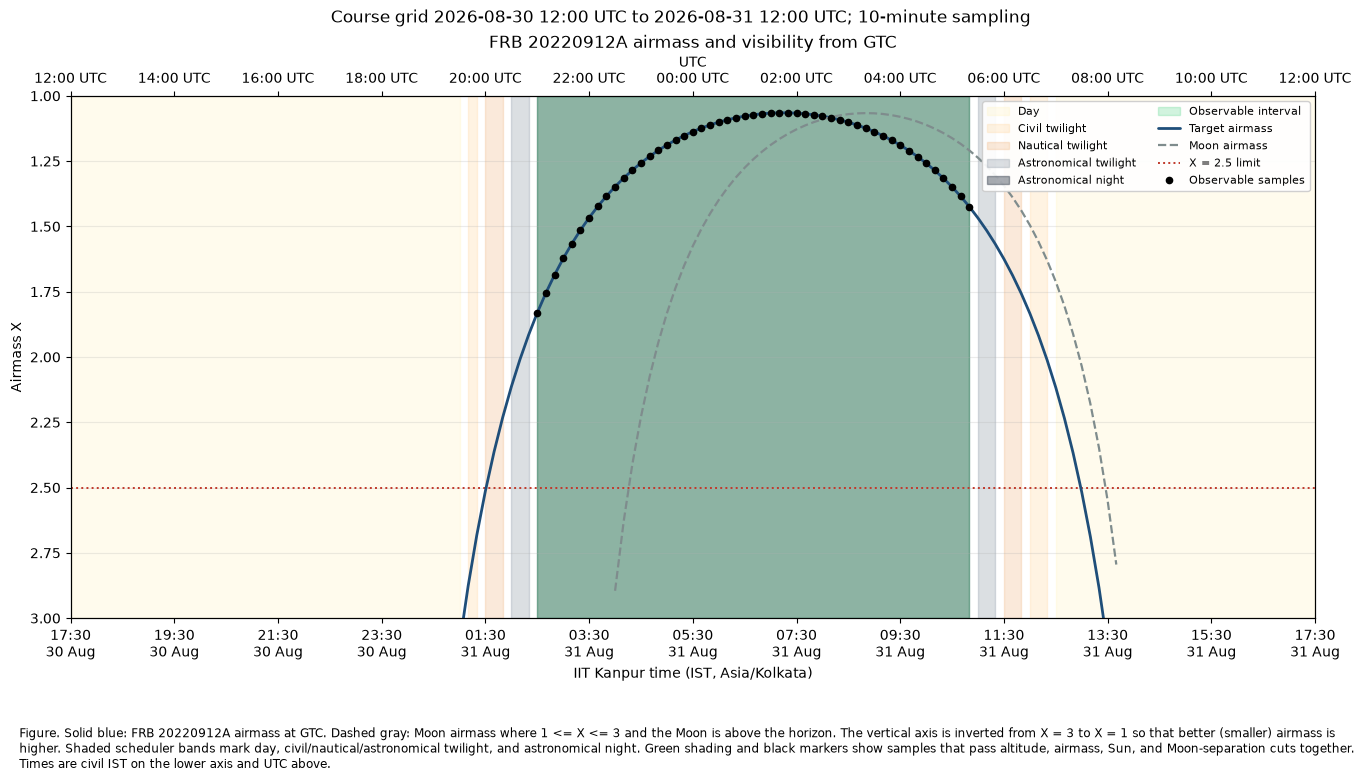

Saved: /Users/anila/Downloads/assignment_outputs/frb_20220912a_gtc_airmass.png size_bytes= 227206
Scientific conclusion: FRB 20220912A is observable from GTC in 1 interval(s) during this 24 h case. The most favourable window is 2026-08-31 02:30:00 IST to 2026-08-31 10:50:00 IST (2026-08-30 21:00:00 UTC to 2026-08-31 05:20:00 UTC), with best airmass X = 1.065 and midpoint Moon label Bright.
Limitation: a 10-minute grid can shift window edges by up to one cadence step and can miss a visibility spike shorter than 10 minutes.


In [23]:
# Q18. Observing intervals and GTC airmass figure
def stitch_windows(times, visibility_state):
    """Return consecutive inclusive sample-centre intervals.

    Empty input, isolated True samples, separated runs, and a final-sample
    run are all kept. Each window is (start_time, end_time) at sample centres.
    """
    vis = np.asarray(visibility_state, dtype=bool)
    if vis.ndim != 1:
        raise ValueError("visibility_state must be one-dimensional")
    if len(times) != len(vis):
        raise ValueError("times and visibility_state must have the same length")

    windows = []
    in_run = False
    start = None
    for i, flag in enumerate(vis):
        if flag and not in_run:
            start = i
            in_run = True
        elif (not flag) and in_run:
            windows.append((times[start], times[i - 1]))
            in_run = False
    if in_run:
        windows.append((times[start], times[-1]))
    return windows


# Self-check the required edge cases on a tiny Boolean mask.
_demo = Time("2026-01-01T00:00:00") + np.arange(6) * (10 * u.min)
_assert_empty = stitch_windows(_demo, np.zeros(6, dtype=bool))
_assert_isolated = stitch_windows(_demo, np.array([0, 1, 0, 0, 0, 0], dtype=bool))
_assert_separated = stitch_windows(_demo, np.array([1, 1, 0, 1, 0, 0], dtype=bool))
_assert_final = stitch_windows(_demo, np.array([0, 0, 0, 0, 1, 1], dtype=bool))
assert _assert_empty == []
assert len(_assert_isolated) == 1 and _assert_isolated[0][0] == _demo[1] and _assert_isolated[0][1] == _demo[1]
assert len(_assert_separated) == 2
assert _assert_final[0][0] == _demo[4] and _assert_final[0][1] == _demo[5]

observable_windows = stitch_windows(times, preferred_visibility)
print("Number of observable windows:", len(observable_windows))

window_records = []
for i_win, (win_start, win_stop) in enumerate(observable_windows, start=1):
    in_window = (times >= win_start) & (times <= win_stop) & preferred_visibility
    duration = win_stop - win_start
    best_x = float(np.nanmin(target_airmass[in_window]))
    mid_time = win_start + 0.5 * (win_stop - win_start)
    mid_index = int(np.argmin(np.abs((times - mid_time).to_value(u.min))))
    record = {
        "start": win_start,
        "stop": win_stop,
        "duration": duration,
        "best_airmass": best_x,
        "mid_moon": moon_label[mid_index],
        "n_samples": int(np.count_nonzero(in_window)),
    }
    window_records.append(record)
    print(f"Window {i_win}:")
    print("  IST:", format_iitk(win_start), "->", format_iitk(win_stop))
    print("  UTC:", format_utc(win_start), "->", format_utc(win_stop))
    print("  Sample-centre duration:", duration.to(u.hour))
    print("  Samples in window:", record["n_samples"])
    print("  Best target airmass:", best_x)
    print("  Midpoint Moon label:", record["mid_moon"])

if not window_records:
    print("No sample satisfies all four observing conditions on this grid.")


def contiguous_spans(mask):
    spans = []
    in_run = False
    start = None
    for i, flag in enumerate(mask):
        if flag and not in_run:
            start = i
            in_run = True
        elif (not flag) and in_run:
            spans.append((start, i - 1))
            in_run = False
    if in_run:
        spans.append((start, len(mask) - 1))
    return spans


ist_datetimes = [t.to_datetime(timezone=IITK_TIMEZONE) for t in times]
x_ist = mdates.date2num(ist_datetimes)
sun_alt_deg = sun_altitude.to_value(u.deg)

band_defs = [
    (sun_alt_deg > 0.0, "#fff3bf", "Day"),
    ((sun_alt_deg <= 0.0) & (sun_alt_deg > -6.0), "#ffd59a", "Civil twilight"),
    ((sun_alt_deg <= -6.0) & (sun_alt_deg > -12.0), "#f0b27a", "Nautical twilight"),
    ((sun_alt_deg <= -12.0) & (sun_alt_deg > -18.0), "#7f8c9a", "Astronomical twilight"),
    (sun_alt_deg <= -18.0, "#1b2636", "Astronomical night"),
]

fig, ax = plt.subplots(figsize=(13.5, 6.8), layout="constrained")

for mask, color, label in band_defs:
    first = True
    for i0, i1 in contiguous_spans(mask):
        ax.axvspan(
            x_ist[i0],
            x_ist[i1],
            color=color,
            alpha=0.28 if label != "Astronomical night" else 0.38,
            zorder=0,
            label=label if first else None,
        )
        first = False

for i_win, rec in enumerate(window_records):
    x0 = mdates.date2num(rec["start"].to_datetime(timezone=IITK_TIMEZONE))
    x1 = mdates.date2num(rec["stop"].to_datetime(timezone=IITK_TIMEZONE))
    ax.axvspan(
        x0,
        x1,
        color="#2ecc71",
        alpha=0.22,
        zorder=1,
        label="Observable interval" if i_win == 0 else None,
    )

ax.plot(
    x_ist,
    target_airmass,
    color="#1f4e79",
    lw=2.0,
    solid_capstyle="round",
    label="Target airmass",
    zorder=3,
)
ax.plot(
    x_ist,
    moon_airmass,
    color="#7f8c8d",
    ls="--",
    lw=1.6,
    label="Moon airmass",
    zorder=3,
)
ax.axhline(MAX_AIRMASS, color="#c0392b", ls=":", lw=1.4, label="X = 2.5 limit", zorder=2)
ax.plot(
    x_ist[preferred_visibility],
    target_airmass[preferred_visibility],
    "o",
    color="black",
    ms=4.5,
    label="Observable samples",
    zorder=4,
)

ax.set_ylim(3.0, 1.0)
ax.set_xlim(x_ist[0], x_ist[-1])
ax.set_ylabel("Airmass X")
ax.set_xlabel("IIT Kanpur time (IST, Asia/Kolkata)")
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M\n%d %b", tz=IITK_TIMEZONE))
ax.grid(True, axis="y", alpha=0.25)

ax_utc = ax.twiny()
ax_utc.set_xlim(ax.get_xlim())
ax_utc.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax_utc.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M UTC", tz=timezone.utc))
ax_utc.set_xlabel("UTC")

ax.legend(loc="upper right", fontsize=8, framealpha=0.92, ncol=2)
ax.set_title("FRB 20220912A airmass and visibility from GTC")
fig.suptitle("Course grid 2026-08-30 12:00 UTC to 2026-08-31 12:00 UTC; 10-minute sampling")

caption = (
    "Figure. Solid blue: FRB 20220912A airmass at GTC. Dashed gray: Moon airmass "
    "where 1 <= X <= 3 and the Moon is above the horizon. The vertical axis is inverted "
    "from X = 3 to X = 1 so that better (smaller) airmass is higher. Shaded scheduler "
    "bands mark day, civil/nautical/astronomical twilight, and astronomical night. "
    "Green shading and black markers show samples that pass altitude, airmass, Sun, "
    "and Moon-separation cuts together. Times are civil IST on the lower axis and UTC above."
)
fig.text(0.01, -0.06, caption, ha="left", va="top", fontsize=8.5, wrap=True)

airmass_path = OUTPUT_DIR / "frb_20220912a_gtc_airmass.png"
fig.savefig(airmass_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", airmass_path.resolve(), "size_bytes=", airmass_path.stat().st_size)

if window_records:
    best = min(window_records, key=lambda r: r["best_airmass"])
    print(
        "Scientific conclusion: FRB 20220912A is observable from GTC in "
        f"{len(window_records)} interval(s) during this 24 h case. The most favourable "
        f"window is {format_iitk(best['start'])} to {format_iitk(best['stop'])} "
        f"({format_utc(best['start'])} to {format_utc(best['stop'])}), "
        f"with best airmass X = {best['best_airmass']:.3f} and midpoint Moon label "
        f"{best['mid_moon']}."
    )
else:
    print(
        "Scientific conclusion: no 10-minute sample simultaneously satisfies the "
        "altitude, airmass, astronomical-darkness, and Moon-separation limits, so "
        "the source is not observable under the printed GTC rules in this interval."
    )
print(
    "Limitation: a 10-minute grid can shift window edges by up to one cadence step "
    "and can miss a visibility spike shorter than 10 minutes."
)


**Explanation.** `stitch_windows` walks the Boolean mask and returns inclusive sample-centre pairs, including an empty result, isolated points, separated runs, and a run that ends on the last sample. The figure uses an inverted 3-to-1 airmass axis, IST on the main axis, UTC above, twilight/night bands, and green marks for the calculated windows. The 10-minute grid is only a sampled approximation of the true rise and set of each condition.


# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [24]:
# Q19. Single-source GTC visibility on 2026-09-01 (no Moon)
q19_start = Time("2026-09-01T00:00:00", scale="utc")
q19_stop = Time("2026-09-02T00:00:00", scale="utc")
q19_n_steps = int(np.round(((q19_stop - q19_start) / step).to_value(u.dimensionless_unscaled)))
q19_times = q19_start + np.arange(q19_n_steps + 1) * step
assert len(q19_times) == 145

q19_frame = AltAz(obstime=q19_times, location=gtc_location)
q19_altaz = frb_icrs.transform_to(q19_frame)
q19_sun_alt = get_sun(q19_times).transform_to(q19_frame).alt
q19_airmass = np.asarray(q19_altaz.secz, dtype=float)
q19_airmass[(q19_altaz.alt.degree <= 0.0) | ~np.isfinite(q19_airmass) | (q19_airmass < 1.0)] = np.nan

q19_visible = (
    (q19_altaz.alt.degree > 0.0)
    & np.isfinite(q19_airmass)
    & (q19_airmass <= MAX_AIRMASS)
    & (q19_sun_alt.degree <= MAX_SUN_ALTITUDE_DEG)
)

q19_windows = stitch_windows(q19_times, q19_visible)
total_visible = np.count_nonzero(q19_visible) * STEP_MINUTES * u.min

print("Date: 2026-09-01, full UTC day, geometric/airmass/night rule (Moon excluded)")
print("Number of contiguous visibility intervals:", len(q19_windows))
for i_win, (win_start, win_stop) in enumerate(q19_windows, start=1):
    print(f"Interval {i_win}:")
    print("  UTC:", format_utc(win_start), "->", format_utc(win_stop))
    print("  IST:", format_iitk(win_start), "->", format_iitk(win_stop))
    print("  Sample-centre span:", (win_stop - win_start).to(u.hour))
print("Total visible duration (counted samples x 10 min):", total_visible.to(u.hour))
if not q19_windows:
    print("The FRB is not visible from GTC under this rule on 2026-09-01.")


Date: 2026-09-01, full UTC day, geometric/airmass/night rule (Moon excluded)
Number of contiguous visibility intervals: 2
Interval 1:
  UTC: 2026-09-01 00:00:00 UTC -> 2026-09-01 05:20:00 UTC
  IST: 2026-09-01 05:30:00 IST -> 2026-09-01 10:50:00 IST
  Sample-centre span: 5.333333333333333 h
Interval 2:
  UTC: 2026-09-01 21:00:00 UTC -> 2026-09-02 00:00:00 UTC
  IST: 2026-09-02 02:30:00 IST -> 2026-09-02 05:30:00 IST
  Sample-centre span: 3.0 h
Total visible duration (counted samples x 10 min): 8.666666666666666 h


**Explanation.** Q19 reuses the geometric GTC rule only: the repeating FRB must be above the horizon, have $X\le 2.5$, and lie in astronomical night. The Moon is excluded. The result is a set of contiguous UTC/IST windows for one source on one date, not an all-sky map.


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [25]:
# Q20. One-year weekly all-sky GTC visibility animation (bonus)
import imageio

nside = 16
npix = hp.nside2npix(nside)
pix = np.arange(npix)
theta, phi = hp.pix2ang(nside, pix)
sky_pixels = SkyCoord(ra=phi * u.rad, dec=(0.5 * np.pi - theta) * u.rad, frame="icrs")

# Vacuum altitude/airmass from the Q12/Q14 relations, vectorised over HEALPix pixels.
sin_phi = np.sin(gtc_location.lat.radian)
cos_phi = np.cos(gtc_location.lat.radian)
sin_dec_pix = np.sin(sky_pixels.dec.radian)
cos_dec_pix = np.cos(sky_pixels.dec.radian)
ra_pix = sky_pixels.ra.radian

map_start = Time("2026-08-30T00:00:00", scale="utc")
map_step = 7 * u.day
n_maps = int(np.floor(((365 * u.day) / map_step).to_value(u.dimensionless_unscaled))) + 1
map_dates = map_start + np.arange(n_maps) * map_step
assert format_utc(map_dates[0]).startswith("2026-08-30")
assert format_utc(map_dates[-1]).startswith("2027-08-29")

frame_dir = OUTPUT_DIR / "q20_weekly_frames"
frame_dir.mkdir(parents=True, exist_ok=True)

intra_step = 20 * u.min
n_intra = int((24 * u.hour / intra_step).to_value(u.dimensionless_unscaled))
dt_hours = intra_step.to_value(u.hour)

visibility_maps = []
frame_paths = []

print(f"HEALPix nside={nside}, npix={npix}, weekly maps={len(map_dates)}")
print("Intra-night sampling:", intra_step)

for i_date, day0 in enumerate(map_dates):
    day_times = day0 + np.arange(n_intra) * intra_step
    day_frame = AltAz(obstime=day_times, location=gtc_location)
    day_sun_alt = get_sun(day_times).transform_to(day_frame).alt.degree
    night = day_sun_alt <= MAX_SUN_ALTITUDE_DEG
    night_times = day_times[night]

    vis_hours = np.zeros(npix, dtype=float)
    if night_times.size:
        lst = night_times.sidereal_time("apparent", longitude=gtc_location.lon)
        hour_angle_pix = lst.radian[:, np.newaxis] - ra_pix[np.newaxis, :]
        sin_h = (
            sin_phi * sin_dec_pix[np.newaxis, :]
            + cos_phi * cos_dec_pix[np.newaxis, :] * np.cos(hour_angle_pix)
        )
        sin_h = np.clip(sin_h, -1.0, 1.0)
        with np.errstate(divide="ignore", invalid="ignore"):
            pix_airmass = 1.0 / sin_h
        visible = (
            (sin_h > 0.0)
            & np.isfinite(pix_airmass)
            & (pix_airmass >= 1.0)
            & (pix_airmass <= MAX_AIRMASS)
        )
        vis_hours = visible.sum(axis=0).astype(float) * dt_hours

    visibility_maps.append(vis_hours)

    fig_m = plt.figure(figsize=(8.8, 5.2))
    hp.mollview(
        vis_hours,
        fig=fig_m.number,
        coord="C",
        nest=False,
        title="",
        unit="Visible hours",
        min=0.0,
        max=12.0,
        cmap="viridis",
        flip="astro",
        xsize=800,
    )
    hp.graticule(dpar=30, dmer=60, color="white", alpha=0.35)
    hp.projscatter(
        frb_icrs.ra.degree,
        frb_icrs.dec.degree,
        lonlat=True,
        s=28,
        marker="*",
        color="red",
        label=FRB_NAME,
    )
    plt.title(
        f"GTC all-sky visibility  {day0.utc.strftime('%Y-%m-%d')} UTC\n"
        f"night + h>0 + X<=2.5   nside={nside}",
        pad=8,
    )
    frame_path = frame_dir / f"gtc_visibility_{day0.utc.strftime('%Y%m%d')}.png"
    fig_m.savefig(frame_path, dpi=110, bbox_inches="tight", facecolor="white")
    plt.close(fig_m)
    frame_paths.append(frame_path)
    print(
        f"[{i_date+1:02d}/{len(map_dates)}] {day0.utc.strftime('%Y-%m-%d')}  "
        f"max={vis_hours.max():.2f} h  mean={vis_hours.mean():.2f} h  "
        f"visible_frac={(vis_hours > 0).mean():.3f}  {frame_path.name}"
    )

gif_path = OUTPUT_DIR / "gtc_allsky_visibility_2026-08-30_to_2027-08-29.gif"
frames = [imageio.v2.imread(path) for path in frame_paths]
imageio.mimsave(gif_path, frames, duration=0.35, loop=0)

print("Saved weekly frames:", len(frame_paths), "in", frame_dir.resolve())
print("Saved GIF:", gif_path.resolve(), "size_bytes=", gif_path.stat().st_size)
print("First frame:", frame_paths[0].name, "Last frame:", frame_paths[-1].name)


HEALPix nside=16, npix=3072, weekly maps=53
Intra-night sampling: 20.0 min


/Users/anila/anushkaworkspace/Spirals/.venv/lib/python3.14/site-packages/healpy/visufunc.py:225: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


[01/53] 2026-08-30  max=8.67 h  mean=2.60 h  visible_frac=0.575  gtc_visibility_20260830.png
[02/53] 2026-09-06  max=8.67 h  mean=2.60 h  visible_frac=0.576  gtc_visibility_20260906.png
[03/53] 2026-09-13  max=9.00 h  mean=2.70 h  visible_frac=0.587  gtc_visibility_20260913.png
[04/53] 2026-09-20  max=9.00 h  mean=2.70 h  visible_frac=0.586  gtc_visibility_20260920.png
[05/53] 2026-09-27  max=9.33 h  mean=2.80 h  visible_frac=0.597  gtc_visibility_20260927.png
[06/53] 2026-10-04  max=9.67 h  mean=2.90 h  visible_frac=0.609  gtc_visibility_20261004.png
[07/53] 2026-10-11  max=9.67 h  mean=2.90 h  visible_frac=0.609  gtc_visibility_20261011.png
[08/53] 2026-10-18  max=10.00 h  mean=3.00 h  visible_frac=0.620  gtc_visibility_20261018.png
[09/53] 2026-10-25  max=10.00 h  mean=3.00 h  visible_frac=0.620  gtc_visibility_20261025.png
[10/53] 2026-11-01  max=10.33 h  mean=3.10 h  visible_frac=0.631  gtc_visibility_20261101.png
[11/53] 2026-11-08  max=10.33 h  mean=3.10 h  visible_frac=0.631  g

[45/53] 2027-07-04  max=7.00 h  mean=2.10 h  visible_frac=0.521  gtc_visibility_20270704.png
[46/53] 2027-07-11  max=7.00 h  mean=2.10 h  visible_frac=0.520  gtc_visibility_20270711.png
[47/53] 2027-07-18  max=7.00 h  mean=2.10 h  visible_frac=0.521  gtc_visibility_20270718.png
[48/53] 2027-07-25  max=7.33 h  mean=2.20 h  visible_frac=0.530  gtc_visibility_20270725.png
[49/53] 2027-08-01  max=7.67 h  mean=2.30 h  visible_frac=0.543  gtc_visibility_20270801.png
[50/53] 2027-08-08  max=7.67 h  mean=2.30 h  visible_frac=0.543  gtc_visibility_20270808.png
[51/53] 2027-08-15  max=8.00 h  mean=2.40 h  visible_frac=0.554  gtc_visibility_20270815.png
[52/53] 2027-08-22  max=8.33 h  mean=2.50 h  visible_frac=0.564  gtc_visibility_20270822.png
[53/53] 2027-08-29  max=8.67 h  mean=2.60 h  visible_frac=0.575  gtc_visibility_20270829.png
Saved weekly frames: 53 in /Users/anila/Downloads/assignment_outputs/q20_weekly_frames
Saved GIF: /Users/anila/Downloads/assignment_outputs/gtc_allsky_visibility_2

**Explanation.** Each weekly HEALPix map shows how many hours a sky position is observable from GTC on that UTC date under the geometric rule (astronomical night, above the horizon, $X\le 2.5$). The Moon is excluded. The observable band slides in right ascension through the year because astronomical night occurs when the Sun is at the opposite RA; pixels near the Sun are in daytime and drop out, while a circumpolar northern cap around GTC's latitude remains easier to observe. The red star marks FRB 20220912A.


## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
